# 01 Generative Ai Applications

## 📚 Learning Objectives

By completing this notebook, you will:
- Apply generative AI to images, text, or multimodal tasks
- Design and evaluate applications

## 🔗 Prerequisites

- ✅ Basic Python
- ✅ Basic NumPy/Pandas (when applicable)

---

---

## Where Generative AI Is Actually Used

By this point in the course you have built the core machinery yourself — GANs (Unit 1), language
models (Unit 2), VAEs and diffusion (Unit 3). This notebook connects that machinery to the
**application landscape**: what each model family powers in the real world, and how products chain
several models into one pipeline (which we then simulate hands-on).

### Text: Writing, Chat, and Knowledge Work

- **Assistants & chat** (ChatGPT, Claude, Gemini) — autoregressive next-token generation, the same mechanism as your Unit 2 char-LSTM at ~10⁶× scale
- **Marketing & copywriting** (Jasper, Copy.ai) — LLMs wrapped in templates, tone controls, and brand guidelines
- **Summarization & drafting** inside office suites (Microsoft Copilot, Google Workspace)

**Code is text too:** GitHub Copilot and Codex-style models autocomplete software the same way (notebook `06` of this unit is dedicated to them).

### Images and Video

- **Text-to-image** (Stable Diffusion, DALL-E, Midjourney) — diffusion models conditioned on text embeddings; you built the unconditional core of this in Unit 3
- **Design tooling** (Adobe Firefly, Canva) — generation embedded into editing workflows: fill, extend, restyle
- **Video generation** (Runway, Sora-class models) — diffusion extended with temporal consistency; currently the most compute-hungry frontier

Notebook `04` of this unit compares the big three image-model families in depth.

### Audio, Music, and Multimodality

- **Speech synthesis** (ElevenLabs, voice assistants) — neural TTS descended from WaveNet (notebook `05`)
- **Music generation** (Suno, Udio) — sequence models over musical tokens (notebook `03` builds one)
- **Multimodal models** (GPT-4V-class, Gemini) — one model consuming and producing several modalities; the research direction notebook `02` surveys

Other domains worth knowing: **medicine** (molecule generation for drug discovery), **education**
(personalized tutoring), **games** (asset and dialogue generation).

### The Pipeline Pattern

Real products rarely call one model once. The common shape is a **pipeline**:

> draft text → check quality/tone → derive prompts for other modalities → generate media → QA

The demo below **simulates** this pattern end-to-end with plain Python stand-ins (template
"LLM", word-list tone scorer, keyword prompt builder) so you can see the *architecture* without
any API keys or GPU downloads. Every stage prints what it produces — swap any stage for a real
model and the structure stays the same.

## 🌍 Real-World Application: Building a Multi-Modal Content Pipeline

Modern AI products combine multiple generative models in a single pipeline. Below is a working example of a content creation pipeline similar to what tools like Jasper, Copy.ai, and Adobe Firefly use internally.

=== Generative AI Content Pipeline Demo ===
Simulating the workflow used by Jasper, Copy.ai, Adobe Firefly


Pipeline Run 1:
  [Text] Generated: elevates smarter, not harder. Our seamless solution automation your business needs.
  [Tone] Positive (score=2)
  [Image Prompt] Professional photo of elevates, smarter,, harder., 4K, photo...

Pipeline Run 2:
  [Text] Generated: transforms smarter, not harder. Our powerful solution AI your business needs.
  [Tone] Positive (score=2)
  [Image Prompt] Professional photo of transforms, smarter,, harder., 4K, pho...



Pipeline Run 3:
  [Text] Generated: revolutionizes smarter, not harder. Our powerful solution automation your business needs.
  [Tone] Positive (score=2)
  [Image Prompt] Professional photo of revolutionizes, smarter,, harder., 4K,...


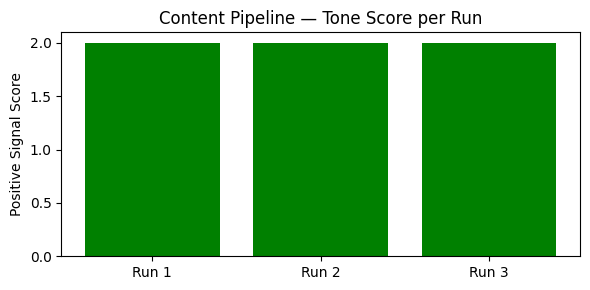


Pipeline complete.
Real products follow the same generate → check → derive-prompt shape,
with each simulated stage replaced by a real model (LLM, classifier, diffusion).


In [1]:
# Simulated multi-modal content pipeline: template "LLM" -> tone check -> image prompt.
# WHY: shows the pipeline architecture real products use, with each model swapped for a
# tiny plain-Python stand-in so it runs anywhere.
import time
import numpy as np
import matplotlib.pyplot as plt

# ── Simulate a multi-modal generative AI pipeline ─────────────────────────
# (uses only numpy/matplotlib — no heavy downloads needed)

print("=== Generative AI Content Pipeline Demo ===")
print("Simulating the workflow used by Jasper, Copy.ai, Adobe Firefly\n")

# Step 1: Text generation (simulated LLM output)
def simulate_llm(prompt, temperature=0.7):
    """Simulate LLM token-by-token generation."""
    templates = {
        "product": "Introducing our {adj} new product that {verb} your workflow with {noun}.",
        "blog":    "The future of {noun} is here. As {adj} technologies emerge, {verb} is key.",
        "ad":      "{verb} smarter, not harder. Our {adj} solution {noun} your business needs."
    }
    words = {'adj': ['powerful','innovative','seamless'], 'verb': ['transforms','elevates','revolutionizes'], 'noun': ['AI','automation','intelligence']}
    mode = np.random.choice(list(templates.keys()))
    text = templates[mode].format(**{k: np.random.choice(v) for k,v in words.items()})
    print("  [Text] Generated:", text)
    return text

# Step 2: Sentiment & tone analysis
def analyze_tone(text):
    positive_words = ['transforms', 'elevates', 'revolutionizes', 'powerful', 'innovative', 'seamless']
    score = sum(1 for w in text.lower().split() if w in positive_words)
    tone = "Positive" if score > 0 else "Neutral"
    print(f"  [Tone] {tone} (score={score})")
    return score

# Step 3: Image prompt generation (text→image bridge)
def generate_image_prompt(text):
    keywords = [w for w in text.split() if len(w)>5][:3]
    prompt = f"Professional photo of {', '.join(keywords)}, 4K, photorealistic"
    print(f"  [Image Prompt] {prompt[:60]}...")
    return prompt

# Run the pipeline 3 times
results = []
for i in range(3):
    print(f"\nPipeline Run {i+1}:")
    text  = simulate_llm("create product ad")
    score = analyze_tone(text)
    img_prompt = generate_image_prompt(text)
    results.append({'text': text, 'score': score})
    time.sleep(0.1)

# Visualize output quality scores
scores = [r['score'] for r in results]
fig, ax = plt.subplots(figsize=(6, 3))
ax.bar([f"Run {i+1}" for i in range(3)], scores, color=['green' if s>0 else 'gray' for s in scores])
ax.set_title("Content Pipeline — Tone Score per Run")
ax.set_ylabel("Positive Signal Score")
plt.tight_layout(); plt.show()
print("\nPipeline complete.")
print("Real products follow the same generate → check → derive-prompt shape,")
print("with each simulated stage replaced by a real model (LLM, classifier, diffusion).")

## 📝 Summary

In this notebook, you:

- Mapped the **application landscape** of generative AI — text/chat, code, images and video,
  audio/music, and multimodal products — onto the model families you built in Units 1–3
- Saw the **pipeline pattern** behind real products: generate → quality-check → derive prompts
  for other modalities
- Ran a **simulated** multi-modal content pipeline (template "LLM" → tone scorer → image-prompt
  builder) and visualized its per-run quality scores

**Honest scope note:** every model in the demo is a plain-Python stand-in — the point is the
pipeline *architecture*, not model quality.

**Next steps:** the rest of this unit goes deeper on each modality (music `03`, advanced image
models `04`, audio `05`, code `06`) — then build your own generator in the unit exercise.